# Predikce srdečního selhání za využití Náhodného Lesa


* V tomto projektu se zabývám klasifikační úlohou zaměřenou na predikci srdečního onemocnění na základě klinických dat pacientů. Cílem je navrhnout a vyhodnotit model, který dokáže spolehlivě rozlišit mezi pacienty se srdečním onemočněním a zdravými jedinci. Součástí řešení je pipeline předzpracování dat, transformace příznaků a ladění hyperparametrů několika modelů.
* Trénovací data máme v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:

* Age: věk pacienta [roky]
* Sex: pohlaví pacienta [M: muž, F: žena]
* Chest Pain Type: typ bolesti na hrudi [TA: typická angina pectoris, ATA: atypická angina pectoris, NAP: neanginózní bolest, ASY: bez příznaků]
* Resting BP: krevní tlak v klidu [mm Hg]
* Cholesterol: sérový cholesterol [mm/dl]
* Fasting BS: hladina cukru v krvi nalačno [1: pokud BS nalačno > 120 mg/dl, 0: jinak]
* Resting ECG: výsledky elektrokardiogramu v klidu
[Normal: normální, ST: s abnormalitou ST-T vlny (inverze T vlny a/nebo elevace nebo deprese ST > 0,05 mV), LVH: s pravděpodobnou nebo definitivní hypertrofií levé komory podle Estesových kritérií].
* Max HR: maximální dosažená srdeční frekvence [Číselná hodnota mezi 60 a 202]
* Exercise Angina: angina pectoris vyvolaná zátěží [Y: Ano, N: Ne]
* Old peak: starý vrchol = ST [Číselná hodnota měřená v depresi]
* ST _Slope: sklon segmentu ST při maximální zátěži [Up: vzestupný, Flat: plochý, Down: sestupný]
* Heart Disease: **cílová proměnná, kterou predikujeme** [1: srdeční onemocnění, 0: normální]

## Jak budeme postupovat
  * Načteme data ze souboru `data.csv`. Kvůli malému množství dat nebudeme rozdělovat na trénovací, validační a testovací, ale využijeme křižovou validaci.
  * Provedeme základní předzpracování dat:
    * Projdeme jednotlivé příznaky a transformujeme je do vhodné podoby pro použití ve vybraném klasifikačním modelu.
  * Vytvoříme **vlastní implementaci náhodného lesa**.
  * Na připravená data postupně aplikujeme implementaci modelu náhodného lesa a dále **rozhodovací strom** a **metodu nejbližších sousedů**).
    * Budeme experimentovat s normalizací, pokud pro daný model očekáváte její příznivý vliv.
    * Vybereme hlavní hyperparametry k ladění a najdeme jejich nejlepší hodnoty.
  * Ze všech zkoušených možností v předchozím kroku vybereme finální model a odhadneme, jakou **přesnost** můžete očekávat na nových datech, která jsme doposud neměli k dispozici.
  * Nakonec model použijeme pro predikci pacientů ze souboru `evaluation.csv`

### Očištění a úprava dat

In [111]:
import pandas as pd
import numpy as np
import seaborn as sns, matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay

from pandas import CategoricalDtype

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 23

In [112]:
df = pd.read_csv("data.csv")
print(df.shape)
df.info()

(734, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              734 non-null    int64  
 1   Age             734 non-null    int64  
 2   Sex             734 non-null    object 
 3   ChestPainType   734 non-null    object 
 4   RestingBP       734 non-null    int64  
 5   Cholesterol     734 non-null    int64  
 6   FastingBS       734 non-null    int64  
 7   RestingECG      734 non-null    object 
 8   MaxHR           734 non-null    int64  
 9   ExerciseAngina  734 non-null    object 
 10  Oldpeak         734 non-null    float64
 11  ST_Slope        734 non-null    object 
 12  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 74.7+ KB


Dataset má 734 datových bodů a 13 příznaků, z toho jeden (**HeartDisease**) je zkoumaný.

,count
Cholesterol,
0,144
204,9
230,8
216,8
211,8
...,...
185,1
468,1
279,1


,count
Sex,
M,575
F,159


,count
ChestPainType,
ASY,392
NAP,163
ATA,140
TA,39


,count
RestingECG,
Normal,433
LVH,153
ST,148


,count
ExerciseAngina,
N,434
Y,300


,count
ST_Slope,
Flat,361
Up,319
Down,54


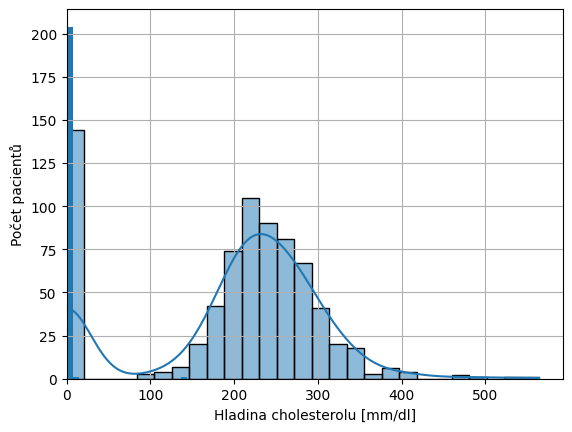

In [113]:
fig, ax = plt.subplots()
sns.histplot(ax=ax, data=df["Cholesterol"], kde=True)
ax.set_xlim(left = 0)
ax.set_xlabel("Hladina cholesterolu [mm/dl]")
ax.set_ylabel("Počet pacientů");
df["Cholesterol"].value_counts().hist(bins=20)
display(pd.DataFrame(df["Cholesterol"].value_counts()))
display(pd.DataFrame(df["Sex"].value_counts()))
display(pd.DataFrame(df["ChestPainType"].value_counts()))
display(pd.DataFrame(df["RestingECG"].value_counts()))
display(pd.DataFrame(df["ExerciseAngina"].value_counts()))
display(pd.DataFrame(df["ST_Slope"].value_counts()))

V datasetu máme 5 příznaků typu *object* a jeden zajímavý příznak **Cholesterol**. Zatímco většina hodnot cholesterolu se pohybuje v tříciferných hodnotách se zřejmě normálním rozdělením, podezřele častá hodnota je 0. To je jasný ukazatel, že jde o nevyplněnou hodnotu. Tyto nevyplněné hodnoty doplníme medianem trénovací sady.
Příznaky **Sex** a **ExerciseAngina** jsou binární, převedeme je tedy na hodnoty 0 a 1. Příznaky **ChestPainType**, **RestingECG** a **ST_Slope** jsou kategorické a zakódujeme pomocí One-Hot encodingu.
U příznaku **Oldpeak** je také nejvíce hodnot rovné nule, ale tam se hodnoty pohybují v nižších jednotkách, nelze tedy s jistotou říct, zda se jedná o nevyplněné hodnoty nebo o skutečná data.

In [114]:
sex_cat = CategoricalDtype(categories=["M", "F"], ordered=True)
df["Sex"] = df["Sex"].astype(sex_cat)
df["Sex"] = df["Sex"].cat.codes

exe_ang_cat = CategoricalDtype(categories=["N", "Y"], ordered=True)
df["ExerciseAngina"] = df["ExerciseAngina"].astype(exe_ang_cat)
df["ExerciseAngina"] = df["ExerciseAngina"].cat.codes

In [115]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
# medián, který vypočteme z trénovací sady nesmíme kontaminovat nulami... Hodnoty vypočteme z trénovací sady po rozdělení datasetu

In [116]:
# Předpokládáme, že se v nových datech nevyskytnou nové kategorie
df["ChestPainType"] = df["ChestPainType"].astype("category")
df["RestingECG"] = df["RestingECG"].astype("category")
df["ST_Slope"] = df["ST_Slope"].astype("category")


In [117]:
df = pd.get_dummies(df)

Vzhledem k malému počtu dat (734) jsem se rozhodl, že půjdu cestou křížové validace.

In [118]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop(columns=["HeartDisease"]), df["HeartDisease"], test_size=0.2, train_size=0.8, random_state=RANDOM_STATE)

In [119]:
chol_mean = Xtrain["Cholesterol"].mean()
Xtrain["Cholesterol"] = Xtrain["Cholesterol"].fillna(chol_mean)
Xtest["Cholesterol"] = Xtest["Cholesterol"].fillna(chol_mean)

### Příprava modelu náhodného lesu

In [120]:

class CustomRandomForest:

    def __init__(self, n_estimators, max_samples, max_depth):
        self.estimators = [DTC(max_depth = max_depth, random_state=RANDOM_STATE+i) for i in range(n_estimators)]
        self.max_samples = max_samples


    def fit(self, X, y):
        for i, estimator in enumerate(self.estimators):
            merged = pd.DataFrame(pd.concat([X, y], axis=1))
            # Zajistíme, aby každý model měl skutečně rozdílné rozdělení (randomstate + i) a aby bylo možné vybírat opakovaně
            subset = merged.sample(frac=self.max_samples, random_state=RANDOM_STATE + i, replace = True)
            Xsubset = subset[X.columns]
            ysubset = subset[y.name]
            estimator.fit(Xsubset, ysubset)


    def predict(self, X):
        ypredicted = self.predict_proba(X)
        ypredicted = (ypredicted >= (0.5)).astype(int)

        return ypredicted

    def predict_proba(self, X):
        yproba = np.zeros((X.shape[0],))
        for i, estimator in enumerate(self.estimators):
            yproba += estimator.predict(X)
        yproba /= len(self.estimators)

        # Vracíme aritmetický průměr predikcí jednotlivých stromů
        return yproba


### Ladění hyperparametrů pro náhodný les
Nyní najděme nejlepší hyperparametry pro CustomRandomForrest pomocí zmíněné křížové validace.
Protože je výpočetně náročná stejně jako náhodný les jako takový, nemůžeme vyzkoušet příliš velké množství hypermarametrů.
Zkusíme některé a pak uvidíme, jestli nebude mít smysl zkoušet dál.

In [121]:

def find_hyper_param_crf(param_comb):
    best_acc = 0
    best_params = None;

    kf = KFold(n_splits = 5)
    for params in param_comb:
        fold_acc = []
        for train_index, val_index in (kf.split(Xtrain)):
            tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
            ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]
            clf = CustomRandomForest(**params)
            clf.fit(tX_train, ty_train)
            fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
        acc = np.mean(fold_acc)
        if acc > best_acc:
            best_acc = acc
            best_params = params
    return best_acc, best_params

param_grid = {
    "n_estimators": [5, 10, 15, 20, 30],
    "max_samples": np.linspace(0.3, 1.2, 5),
    "max_depth": range(1, 15, 2),
}
param_comb = ParameterGrid(param_grid)
best_acc, best_params = find_hyper_param_crf(param_comb)

print("Best accuracy:", best_acc, "with params:", best_params)
crf_best = CustomRandomForest(**best_params)
crf_best.fit(Xtrain, ytrain)

Best accuracy: 0.8688396349413299 with params: {'max_depth': 5, 'max_samples': np.float64(0.75), 'n_estimators': 30}


Z výsledku je patrné, že počet 30 je na konci našeho "intervalu". Budeme tedy experimentovat s větším počtem stromů.

In [122]:
param_grid = {
    "n_estimators": [40, 55, 80],
    "max_samples": np.linspace(0.3, 1.2, 5),
    "max_depth": range(1, 15, 2),
}
param_comb = ParameterGrid(param_grid)

best_acc, best_params = find_hyper_param_crf(param_comb)

print("Best accuracy:", best_acc, "with params:", best_params)


Best accuracy: 0.8688396349413299 with params: {'max_depth': 5, 'max_samples': np.float64(0.75), 'n_estimators': 40}


In [123]:
param_grid = {
    "n_estimators": [1000],
    "max_samples": np.linspace(0.2, 0.6, 3),
    "max_depth": range(4, 15, 2),
}
param_comb = ParameterGrid(param_grid)

best_acc, best_params = find_hyper_param_crf(param_comb)

print("Best accuracy:", best_acc, "with params:", best_params)


Best accuracy: 0.858597711140084 with params: {'max_depth': 6, 'max_samples': np.float64(0.4), 'n_estimators': 1000}


Nejlepšího výsledku (0.869) jsme dosáhli s parametry {'max_depth': 5, 'max_samples': np.float64(0.75), 'n_estimators': 30}


### Ladění hyperparametrů rozhodovacího stromu a KNN
Nyní zkusme dva další modely od scikitu - rozhodovací strom a metodu nejbližších sousedů.
Zatímco rozhodovací strom je vhodný pro svojí snadnou intepretovatelnost, a jednoduchost, metoda KNN je funguje na principu podobnosti pacientů. To se může hodit - pokud zkoumáme pacienta, můžou být nejvíce vypovídající právě ti nejpodobnější pacienti.

In [124]:
### Rozhodovací strom
best_acc = 0
best_params = None;

param_grid = {
    'max_depth': range(1,31),
    'criterion': ['entropy', 'gini']
}
param_comb = ParameterGrid(param_grid)
kf = KFold(n_splits = 5)
for params in param_comb:
    fold_acc = []
    for train_index, val_index in (kf.split(Xtrain)):
        tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
        ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]
        clf = DTC(**params, random_state=RANDOM_STATE)
        clf.fit(tX_train, ty_train)
        fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
    acc = np.mean(fold_acc)
    if acc > best_acc:
        best_acc = acc
        best_params = params

print("Best accuracy:", best_acc, "with params:", best_params)
dt_best = DTC(**best_params)
dt_best.fit(Xtrain, ytrain);

Best accuracy: 0.8348109517601043 with params: {'criterion': 'entropy', 'max_depth': 4}


In [125]:
### N nejbližších sousedů
param_grid = {
    'n_neighbors': range(2,15),
    'metric': ['minkowski'],
    'p': [1, 2, 3, 4, 5],
    'weights': ['uniform', 'distance'],
}
best_acc = 0
best_params = None;
param_comb = ParameterGrid(param_grid)
kf = KFold(n_splits = 5)
for params in param_comb:
    fold_acc = []
    for train_index, val_index in (kf.split(Xtrain)):
        tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
        ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]
        clf = KNeighborsClassifier(**params)
        clf.fit(tX_train, ty_train)
        fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
    acc = np.mean(fold_acc)
    if acc > best_acc:
        best_acc = acc
        best_params = params
print("Best accuracy:", best_acc, "with params:", best_params)



Best accuracy: 0.6970013037809648 with params: {'metric': 'minkowski', 'n_neighbors': 13, 'p': 1, 'weights': 'distance'}


Model KNN je opravdu citlivý na škálování dat, proto máme nyní výrazně horší výsledky, než s předchozími modely. Data je třeba nejprve naškálovat.

In [126]:

param_grid = {
    'n_neighbors': range(2,15),
    'metric': ['minkowski'],
    'p': [1, 2, 3, 4, 5],
    'weights': ['uniform', 'distance'],
}
best_acc = 0
best_params = None;
param_comb = ParameterGrid(param_grid)
kf = KFold(n_splits = 5)
for params in param_comb:
    fold_acc = []
    for train_index, val_index in (kf.split(Xtrain)):

        tX_train, tX_val = Xtrain.iloc[train_index,:], Xtrain.iloc[val_index,:]
        ty_train, ty_val = ytrain.iloc[train_index], ytrain.iloc[val_index]

        scaler = StandardScaler()
        tX_train = scaler.fit_transform(tX_train)
        tX_val = scaler.transform(tX_val)

        clf = KNeighborsClassifier(**params)
        clf.fit(tX_train, ty_train)
        fold_acc.append(metrics.accuracy_score(ty_val, clf.predict(tX_val)))
    acc = np.mean(fold_acc)
    if acc > best_acc:
        best_acc = acc
        best_params = params

knn_scaler = StandardScaler()
knn_X_train = knn_scaler.fit_transform(Xtrain)
knn_X_test = knn_scaler.transform(Xtest)

knn_best = KNeighborsClassifier(**best_params)
knn_best.fit(knn_X_train, ytrain);
print("Best accuracy:", best_acc, "with params:", best_params)

Best accuracy: 0.8721570331739823 with params: {'metric': 'minkowski', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}


KNN je na metrice accuracy dokonce o trochu lepší než náhodný les se svými 0.872 poměrně blízko. Rozdíl je ale malý.

### Vykreslení ROC křivky a F1 skóre
Nyní pro jednotlivé nejlepší modely vykreslíme ROC křivku a F1 skóre

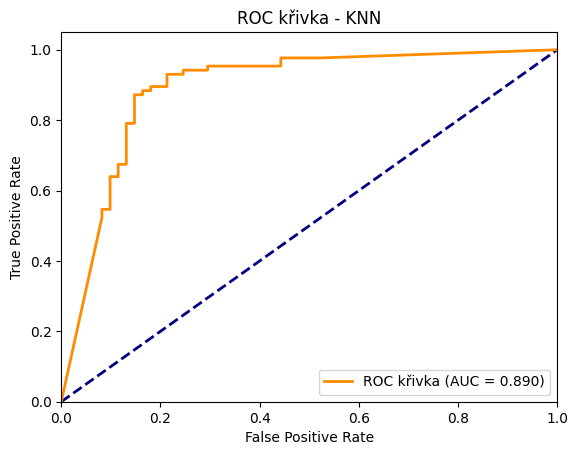

F1 skóre 	- KNN : 0.8771929824561403
AUC 		- KNN : 0.8904879908501715


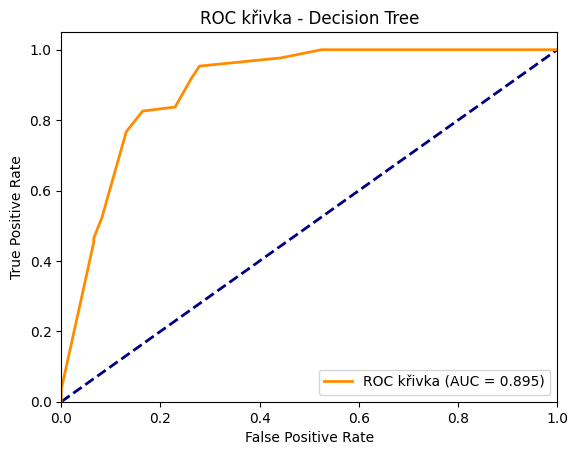

F1 skóre 	- Decision Tree : 0.8372093023255814
AUC 		- Decision Tree : 0.8952535264963781


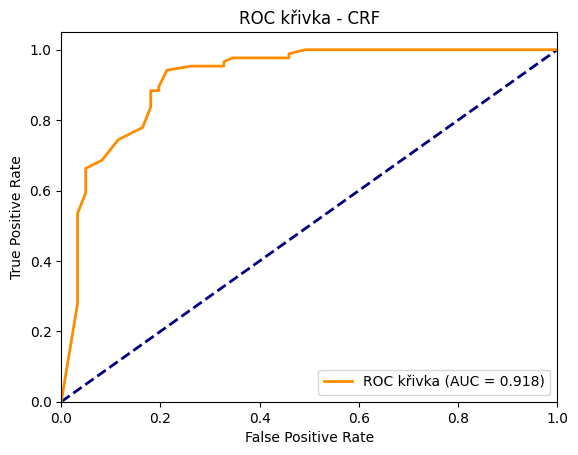

F1 skóre 	- CRF : 0.8913043478260869
AUC 		- CRF : 0.9175562333206252


In [127]:

def metrics_and_f1(y, yprob, ypred, title):
    AUC = roc_auc_score(y, yprob)
    fpr, tpr, thresholds = roc_curve(y, yprob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC křivka (AUC = {AUC:.3f})")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC křivka -"+ " " + title)
    plt.legend(loc="lower right")
    plt.show()
    print("F1 skóre \t-", title, ":" , f1_score(y, ypred))
    print("AUC \t\t-", title, ":", AUC)

y_prob_knn = knn_best.predict_proba(knn_X_test)[:, 1]
y_pred_knn = knn_best.predict(knn_X_test)
metrics_and_f1(ytest, y_prob_knn, y_pred_knn, "KNN")

y_prob_dt = dt_best.predict_proba(Xtest)[:, 1]
y_pred_dt = dt_best.predict(Xtest)
metrics_and_f1(ytest, y_prob_dt, y_pred_dt, "Decision Tree")

y_prob_crf = crf_best.predict_proba(Xtest)
y_pred_crf = crf_best.predict(Xtest)
metrics_and_f1(ytest, y_prob_crf, y_pred_crf, "CRF")


Model náhodného lesa má ze tří největší AUC (0,918), to měří schopnost modelu rozlišovat mezi třídami napříč různými rozhodovacími prahy. Zároveň má největší F1 skóre, které by nás zajímalo hlavně při nevyváženosti predikovaného příznaku. Navíc u medicínských modelů je mnohem důležitější minimalizovat falešně negativní predikce, tyto metriky lépe zachycují chování modelu v situacích, kdy je důležité minimalizovat falešně negativní predikce.

### Očekávaná přesnost na testovací množině

In [128]:
expected_accuracy = metrics.accuracy_score(ytest, crf_best.predict(Xtest))
print("Expected accuracy:", expected_accuracy)

Expected accuracy: 0.8639455782312925


Očekávaná přesnost na testovaích datech je přibližně 86,4%

Ještě se podívejme na Confusion matrix, abychom vyhodnotili, jak moc model predikuje falešně pozitivně nebo falešně negativně:

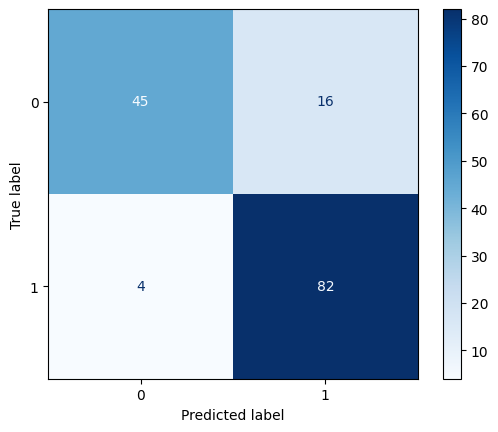

              precision    recall  f1-score   support

           0       0.92      0.74      0.82        61
           1       0.84      0.95      0.89        86

    accuracy                           0.86       147
   macro avg       0.88      0.85      0.85       147
weighted avg       0.87      0.86      0.86       147



In [129]:
ConfusionMatrixDisplay.from_predictions(ytest, crf_best.predict(Xtest),cmap='Blues')
plt.show()
from sklearn.metrics import classification_report
print(classification_report(ytest, crf_best.predict(Xtest)))

Náš model vykazuje vyšší recall než precision pro detekci onemocnění, což znamená, že spolehlivě zachytí většinu nemocných pacientů, i za cenu vyššího počtu falešně pozitivních predikcí. Tento přístup je v medicínském kontextu vhodný.

### Vyhodnocení evaluation.csv s CustomRandomForrest

In [130]:
eval = pd.read_csv("evaluation.csv")


eval["ChestPainType"] = eval["ChestPainType"].astype("category")
eval["RestingECG"] = eval["RestingECG"].astype("category")
eval["ST_Slope"] = eval["ST_Slope"].astype("category")

eval["ExerciseAngina"] = eval["ExerciseAngina"].astype(exe_ang_cat)
eval["ExerciseAngina"] = eval["ExerciseAngina"].cat.codes

eval["Sex"] = eval["Sex"].astype(sex_cat)
eval["Sex"] = eval["Sex"].cat.codes

eval["Cholesterol"] = eval["Cholesterol"].replace(0, chol_mean)


In [131]:
eval = pd.get_dummies(eval)
yeval = pd.DataFrame(crf_best.predict(eval))
evalids = eval["ID"]

In [132]:
result = pd.concat([evalids, yeval], axis=1, )
result.columns = ["ID", "HeartDisease"]
result.to_csv("results.csv",index=False)

### Závěr
Nejlepších výsledků dosáhl model náhodného lesa, který překonal jak rozhodovací stromy, tak KNN z hlediska AUC i F1 skóre.
Detailní analýza metrik ukázala, že model dosahuje vysoké hodnoty recall (0.95) pro detekci onemocnění, což znamená, že máme velmi malé množství falešně negativních pacientů, což je z medicinského hlediska žádoucí. Na druhou stranu model generuje více falešně pozitivních pacientů, což je přípustné.